# PROBLEM STATEMENT

 Data represents weekly 2018 retail scan data for National retail volume (units) and price. Retail scan data comes directly from retailers' cash registers based on actual retail sales of Hass avocados.

  Starting in 2013, the table below reflects an expanded, multi-outlet retail data set. Multi-outlet reporting includes an aggregation of the following channels: grocery, mass, club, drug, dollar and military.

The Average Price (of avocados) in the table reflects a per unit (per avocado) cost, even when multiple units (avocados) are sold in bags.

The Product Lookup codes (PLU's) in the table are only for Hass avocados. Other varieties of avocados (e.g. greenskins) are not included in this table.

 Some relevant columns in the dataset:

 Date The date of the observation

 Average Price the average price of a single avocado

 type - conventional or organic

 year - the year

 Region - the city or region of the observation

 Total Volume - Total number of avocados sold

 4046 - Total number of avocados with PLU 4046 sold

 4225 - Total number of avocados with PLU 4225 sold

 4770 - Total number of avocados with PLU 4770 sold.

# IMPORTING DATA

 You must install fbprophet package as follows: pip install fbprophet

 If you encounter an error, try: conda install -c conda-forge fbprophet

 Prophet is open source software released by Facebook's Core Data Science team.

 Prophet is a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus holiday effects.

 Prophet works best with time series that have strong seasonal effects and several seasons of historical data.

 For more information, please check this out: https://research.fb.com/prophet-forecasting-at-scale/https://facebook.github.io/prophet/docs/quick_start.html#python-api

Import Libraries

In [1]:
!pip install prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
from prophet import Prophet

Load Dataset

In [3]:
df = pd.read_csv('avocado.csv')
print ("Dataset shape", df.shape)
df.head()

Dataset shape (18249, 14)


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [4]:
df.columns

Index(['Unnamed: 0', 'Date', 'AveragePrice', 'Total Volume', '4046', '4225',
       '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type',
       'year', 'region'],
      dtype='object')

Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


Statistical Summary

In [6]:
df.describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


Check missing value

In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
Date,0
AveragePrice,0
Total Volume,0
4046,0
4225,0
4770,0
Total Bags,0
Small Bags,0
Large Bags,0


Drop Unnecessary Column

In [8]:
df.drop('Unnamed: 0', axis=1, inplace=True)

Convert Date Column

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          18249 non-null  datetime64[ns]
 1   AveragePrice  18249 non-null  float64       
 2   Total Volume  18249 non-null  float64       
 3   4046          18249 non-null  float64       
 4   4225          18249 non-null  float64       
 5   4770          18249 non-null  float64       
 6   Total Bags    18249 non-null  float64       
 7   Small Bags    18249 non-null  float64       
 8   Large Bags    18249 non-null  float64       
 9   XLarge Bags   18249 non-null  float64       
 10  type          18249 non-null  object        
 11  year          18249 non-null  int64         
 12  region        18249 non-null  object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory usage: 1.8+ MB


Sort By Date

In [11]:
#Chronological order matters
df = df.sort_values(by='Date')

Initial Visualization

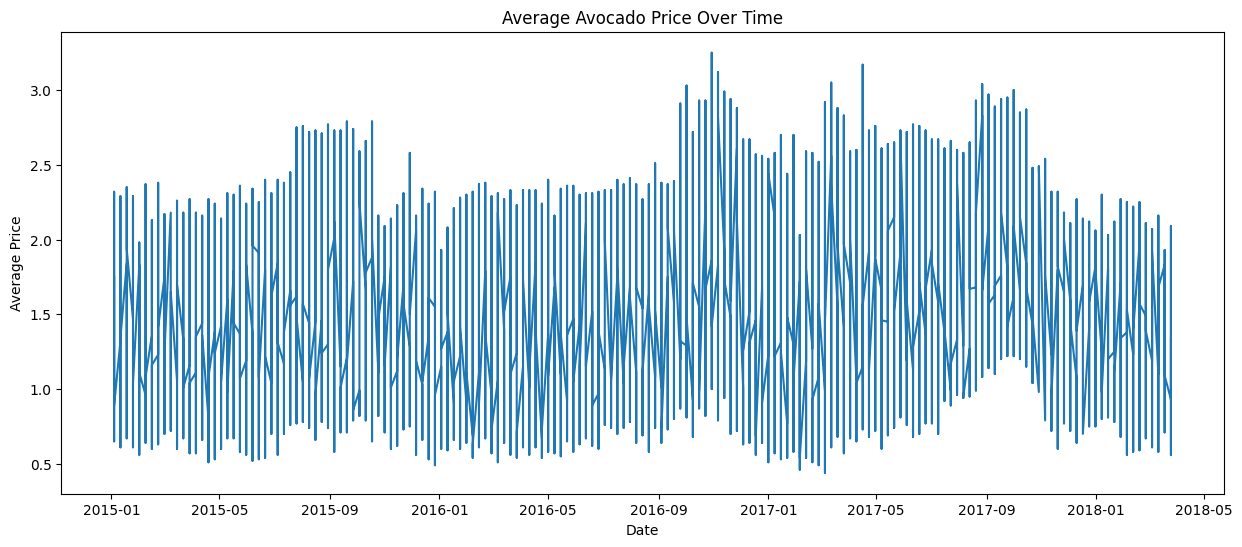

In [12]:
plt.figure(figsize=(15,6))

plt.plot(df['Date'], df['AveragePrice'])

plt.title('Average Avocado Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price')

plt.show()

In [13]:
df['type'].value_counts()

,count
type,
conventional,9126
organic,9123


Region count

In [14]:
df['region'].nunique()

54

Plot Organic vs Conventional Prices

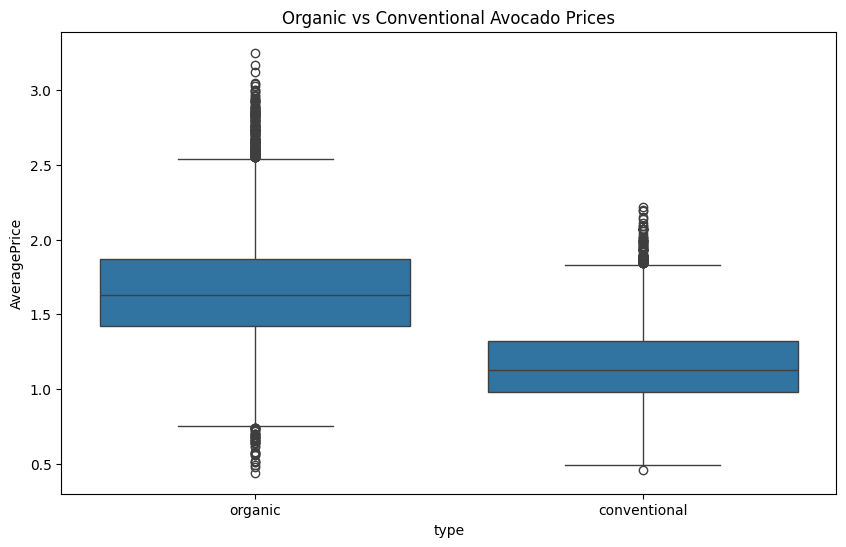

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(x='type', y='AveragePrice', data=df)

plt.title('Organic vs Conventional Avocado Prices')

plt.show()

Correlation Analysis


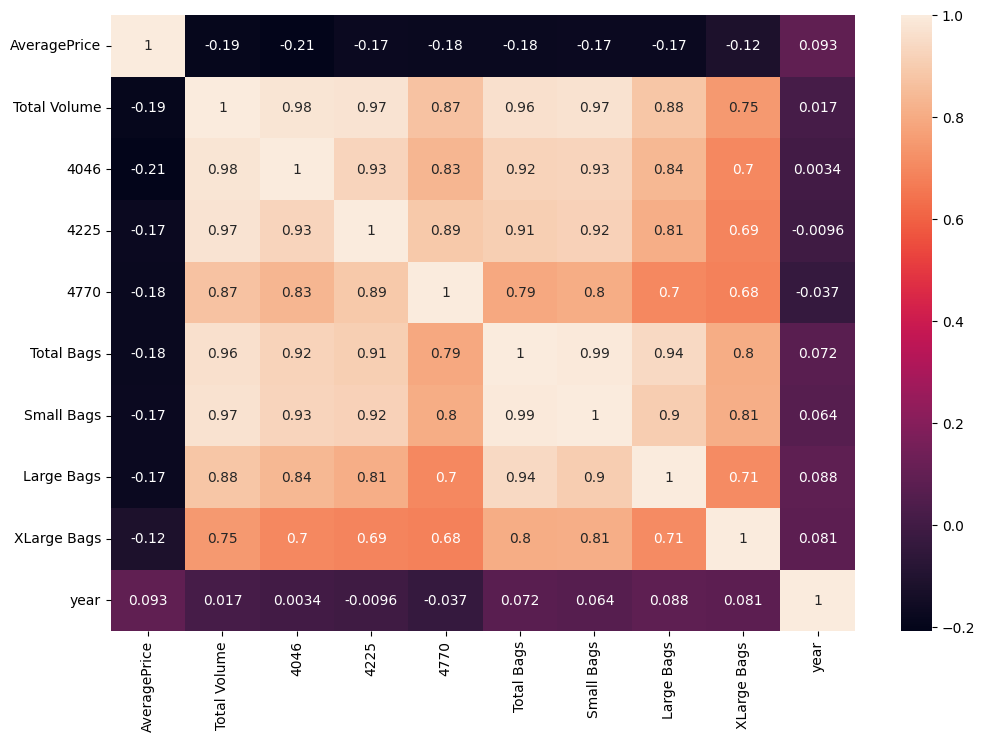

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

Prepare Data For Prophet

In [17]:
prophet_df = df[['Date', 'AveragePrice']]

In [18]:
prophet_df = prophet_df.rename(columns={
    'Date': 'ds',
    'AveragePrice': 'y'
})

In [19]:
prophet_df.head()

,ds,y
11569,2015-01-04,1.75
9593,2015-01-04,1.49
10009,2015-01-04,1.68
1819,2015-01-04,1.52
9333,2015-01-04,1.64


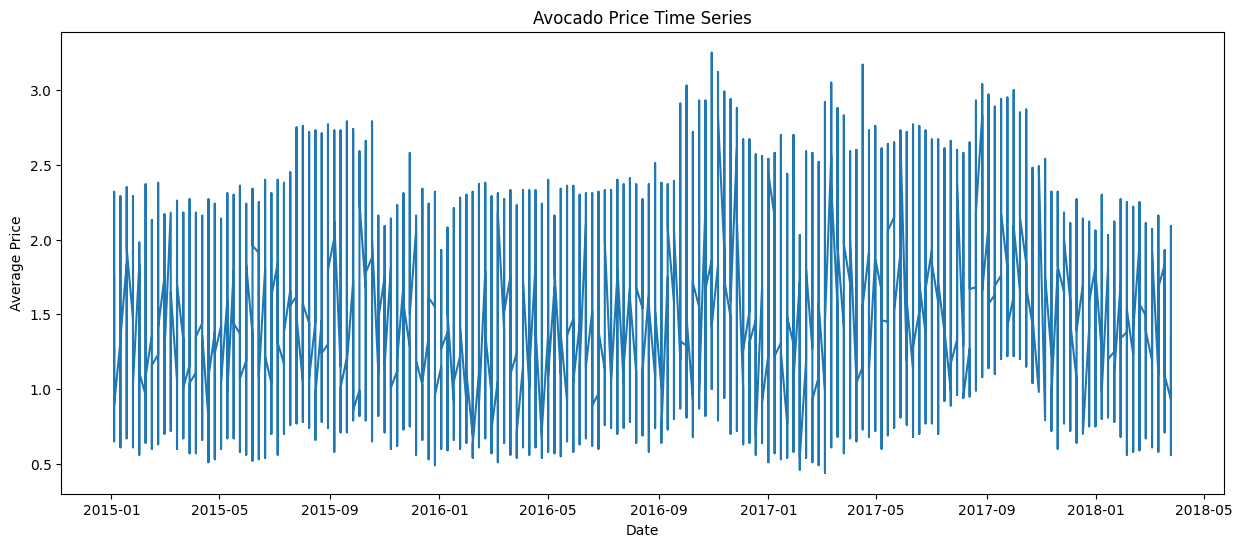

In [20]:
plt.figure(figsize=(15,6))

plt.plot(prophet_df['ds'], prophet_df['y'])

plt.title('Avocado Price Time Series')
plt.xlabel('Date')
plt.ylabel('Average Price')

plt.show()

Create Prophet Model

In [21]:
model = Prophet()

In [22]:
model.fit(prophet_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [23]:
future = model.make_future_dataframe(periods=365)

In [ ]:
future.tail()

,ds
529,2019-03-21
530,2019-03-22
531,2019-03-23
532,2019-03-24
533,2019-03-25


Generate Forecast

In [24]:
forecast = model.predict(future)

View Forecast Output

In [25]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-04,1.501457,0.868002,1.884191,1.501457,1.501457,-0.117841,-0.117841,-0.117841,-0.117841,-0.117841,-0.117841,0.0,0.0,0.0,1.383615
1,2015-01-11,1.496063,0.891139,1.846074,1.496063,1.496063,-0.109453,-0.109453,-0.109453,-0.109453,-0.109453,-0.109453,0.0,0.0,0.0,1.386611
2,2015-01-18,1.490670,0.893403,1.832840,1.490670,1.490670,-0.109033,-0.109033,-0.109033,-0.109033,-0.109033,-0.109033,0.0,0.0,0.0,1.381637
3,2015-01-25,1.485277,0.878779,1.858081,1.485277,1.485277,-0.127702,-0.127702,-0.127702,-0.127702,-0.127702,-0.127702,0.0,0.0,0.0,1.357574
4,2015-02-01,1.479883,0.850448,1.820241,1.479883,1.479883,-0.155584,-0.155584,-0.155584,-0.155584,-0.155584,-0.155584,0.0,0.0,0.0,1.324299


Plot Forecast

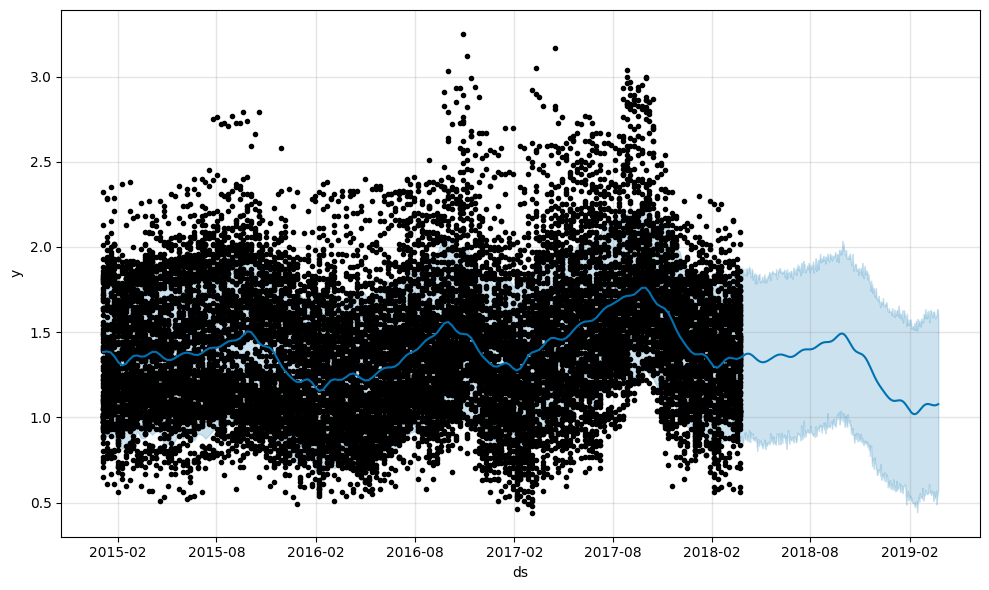

In [26]:
figure = model.plot(forecast)

Plot Forecast Components

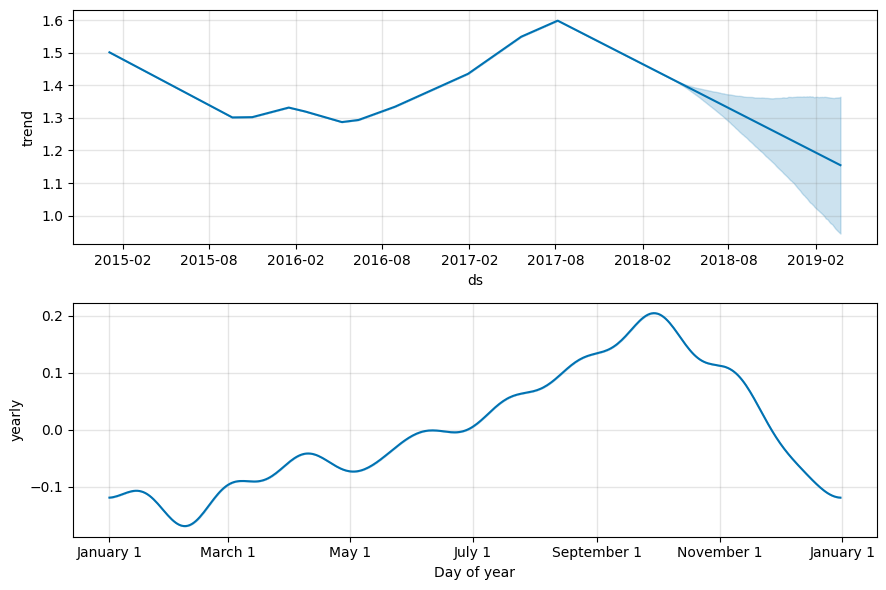

In [27]:
figure2 = model.plot_components(forecast)

View future forecast only

In [28]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
529,2019-03-21,1.071797,0.570101,1.590930
530,2019-03-22,1.072827,0.489470,1.600651
531,2019-03-23,1.074132,0.531770,1.633675
532,2019-03-24,1.075694,0.548267,1.634443
533,2019-03-25,1.077482,0.576291,1.586764
